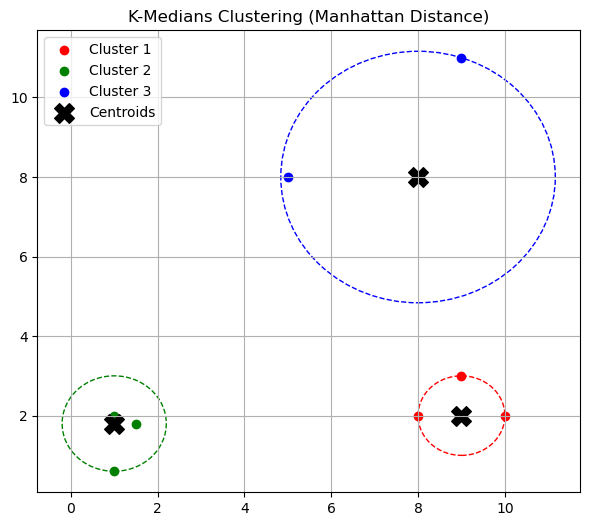

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Sample dataset
X = np.array([
    [1,2], [1.5,1.8], [5,8], [8,8],
    [1,0.6], [9,11], [8,2], [10,2], [9,3]
])

# Number of clusters
k = 3

# Maximum number of iterations
max_iter = 100

# Randomly initialize centroids from dataset
centroids = X[np.random.choice(len(X), k, replace=False)]

# Run K-Medians algorithm
for _ in range(max_iter):

    clusters = [[] for _ in range(k)]

    # Assign points using Manhattan distance
    for point in X:
        distances = np.sum(np.abs(point - centroids), axis=1)
        cluster_index = np.argmin(distances)
        clusters[cluster_index].append(point)

    # Compute new centroids using median
    new_centroids = []

    for i, cluster in enumerate(clusters):
        if len(cluster) > 0:
            new_centroids.append(np.median(cluster, axis=0))
        else:
            new_centroids.append(centroids[i])  # handle empty cluster

    new_centroids = np.array(new_centroids)

    # Stop if centroids stop changing
    if np.allclose(centroids, new_centroids):
        break

    centroids = new_centroids


# Visualization
colors = ['red', 'green', 'blue']

plt.figure(figsize=(7,6))

for i, cluster in enumerate(clusters):

    cluster = np.array(cluster)

    if len(cluster) == 0:
        continue

    # Plot cluster points
    plt.scatter(cluster[:,0], cluster[:,1], c=colors[i], label=f"Cluster {i+1}")

    # Draw circle around cluster
    centroid = centroids[i]
    radius = np.max(np.linalg.norm(cluster - centroid, axis=1))

    circle = plt.Circle(centroid, radius, color=colors[i], fill=False, linestyle="--")
    plt.gca().add_patch(circle)

# Plot centroids
plt.scatter(centroids[:,0], centroids[:,1],
            c='black', marker='X', s=200, label="Centroids")

plt.title("K-Medians Clustering (Manhattan Distance)")
plt.legend()
plt.grid(True)
plt.show()